# E-commerce Product, Conversion Funnel & Growth Analytics

## Business Problem

An e-commerce business wants to understand how customers move from product discovery to purchase and identify the factors affecting conversion performance.

Rather than only reporting KPIs, this analysis will investigate:

- Where customers drop out of the purchase funnel
- Whether conversion performance changes over time
- Which customer, device, channel, product, or category segments contribute to performance changes
- Whether changes are driven by traffic mix or funnel-stage performance
- The potential commercial impact of identified issues
- What actions the business should prioritize

## Core Customer Journey

Product View → Add to Cart → Checkout → Purchase

## Analytical Approach

1. Data Quality Assessment
2. KPI & Metric Definition
3. Baseline Performance Analysis
4. Funnel Analysis
5. Trend & Anomaly Detection
6. Segmentation & Root-Cause Analysis
7. Business Impact Assessment
8. Recommendations & Monitoring Plan

## Tools

Python | Pandas | NumPy | SQL | Excel | Streamlit

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("ecommerce_product_conversion_events.csv")

df.head()

,session_id,customer_id,customer_type,product_id,product_name,category,device,acquisition_channel,city,mrp,discount_pct,selling_price,event_timestamp,event_type,quantity,order_id,revenue
0,S013630,C11505,New,P1060,Loafers 4,Footwear,Desktop,Affiliate,Hyderabad,3572,10,3214.80,2026-01-01 00:00:47,product_view,0,NaN,0.0
1,S001844,C00236,Returning,P1079,Sunscreen 3,Beauty,Mobile,Paid Search,Chennai,3039,25,2279.25,2026-01-01 00:05:00,product_view,0,NaN,0.0
2,S017323,C13542,New,P1085,Backpack 1,Accessories,Mobile,Affiliate,Kolkata,3332,35,2165.80,2026-01-01 00:12:18,product_view,0,NaN,0.0
3,S017323,C13542,New,P1085,Backpack 1,Accessories,Mobile,Affiliate,Kolkata,3332,35,2165.80,2026-01-01 00:15:56,add_to_cart,1,NaN,0.0
4,S001986,C03247,New,P1106,Lamp 2,Home & Living,Mobile,Social,Mumbai,4040,0,4040.00,2026-01-01 00:28:21,product_view,0,NaN,0.0


In [3]:
pd.DataFrame({
    "Metric": ["Rows", "Columns"],
    "Value": [df.shape[0], df.shape[1]]
})

,Metric,Value
0,Rows,68692
1,Columns,17


In [4]:
pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values
})

,Column,Data Type
0,session_id,object
1,customer_id,object
2,customer_type,object
3,product_id,object
4,product_name,object
5,category,object
6,device,object
7,acquisition_channel,object
8,city,object
9,mrp,int64


In [5]:
dataset_profile = pd.DataFrame({
    "Metric": [
        "Total Events",
        "Unique Sessions",
        "Unique Customers",
        "Unique Products",
        "Unique Orders"
    ],
    "Value": [
        len(df),
        df["session_id"].nunique(),
        df["customer_id"].nunique(),
        df["product_id"].nunique(),
        df["order_id"].nunique()
    ]
})

dataset_profile

,Metric,Value
0,Total Events,68692
1,Unique Sessions,30000
2,Unique Customers,14541
3,Unique Products,120
4,Unique Orders,5482


In [6]:
event_summary = (
    df["event_type"]
    .value_counts()
    .rename_axis("Event Type")
    .reset_index(name="Event Count")
)

event_summary["Share (%)"] = (
    event_summary["Event Count"] / len(df) * 100
).round(2)

event_summary

,Event Type,Event Count,Share (%)
0,product_view,44444,64.70
1,add_to_cart,11342,16.51
2,checkout,7408,10.78
3,purchase,5498,8.00


In [7]:
missing_summary = (
    df.isna()
    .sum()
    .to_frame("Missing Count")
)

missing_summary["Missing (%)"] = (
    missing_summary["Missing Count"] / len(df) * 100
).round(2)

missing_summary = (
    missing_summary
    .query("`Missing Count` > 0")
    .sort_values("Missing Count", ascending=False)
)

missing_summary

,Missing Count,Missing (%)
order_id,63194,92.0
acquisition_channel,274,0.4


Duplicate Assessment

In [8]:
duplicate_summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Exact Duplicate Rows",
        "Duplicate Rate (%)"
    ],
    "Value": [
        len(df),
        df.duplicated().sum(),
        round(df.duplicated().mean() * 100, 2)
    ]
})

duplicate_summary

,Metric,Value
0,Total Rows,68692.0
1,Exact Duplicate Rows,137.0
2,Duplicate Rate (%),0.2


## 2. Data Quality Investigation

Before removing or modifying records, each data-quality issue is evaluated in its business context.

Not every missing value represents an error. For example, `order_id` is expected to be null for non-purchase events. Similarly, repeated customer events may be legitimate user behavior rather than duplicate records.

The objective is therefore to distinguish between:

- expected structural nulls,
- genuine data-quality issues,
- legitimate repeated events, and
- exact duplicate records that could distort funnel and conversion metrics.

In [9]:
nulls_by_event = (
    df.groupby("event_type")
      .agg(
          total_events=("event_type", "size"),
          missing_order_id=("order_id", lambda x: x.isna().sum()),
          missing_channel=("acquisition_channel", lambda x: x.isna().sum())
      )
      .reset_index()
)

nulls_by_event

,event_type,total_events,missing_order_id,missing_channel
0,add_to_cart,11342,11342,40
1,checkout,7408,7408,34
2,product_view,44444,44444,173
3,purchase,5498,0,27


### Structural vs Unexpected Missing Values

Missing values are interpreted based on the role of each field in the customer journey.

`order_id` should only exist after a successful purchase, so null order IDs in product-view, cart and checkout events are structurally expected and should not be treated as data-quality failures.

In contrast, `acquisition_channel` describes how a session was acquired and is expected to be available across the customer journey. Missing channel values therefore require further investigation.

In [10]:
purchase_order_check = (
    df.loc[df["event_type"].eq("purchase")]
      .agg(
          purchase_events=("event_type", "size"),
          missing_order_ids=("order_id", lambda x: x.isna().sum()),
          unique_orders=("order_id", "nunique")
      )
)

purchase_order_check

,event_type,order_id
purchase_events,5498.0,NaN
missing_order_ids,NaN,0.0
unique_orders,NaN,5482.0


In [11]:
missing_channel_profile = (
    df.loc[df["acquisition_channel"].isna()]
      .groupby(["event_type", "device"])
      .size()
      .reset_index(name="missing_records")
      .sort_values("missing_records", ascending=False)
)

missing_channel_profile

,event_type,device,missing_records
7,product_view,Mobile,120
6,product_view,Desktop,49
1,add_to_cart,Mobile,27
4,checkout,Mobile,23
10,purchase,Mobile,16
0,add_to_cart,Desktop,11
9,purchase,Desktop,9
3,checkout,Desktop,7
8,product_view,Tablet,4
5,checkout,Tablet,4


In [12]:
session_channel_map = (
    df.dropna(subset=["acquisition_channel"])
      .drop_duplicates("session_id")
      .set_index("session_id")["acquisition_channel"]
)

recoverable_channel = (
    df.loc[df["acquisition_channel"].isna(), "session_id"]
      .map(session_channel_map)
)

channel_recovery_summary = pd.DataFrame({
    "Metric": [
        "Missing Channel Records",
        "Recoverable from Same Session",
        "Still Unresolved"
    ],
    "Value": [
        df["acquisition_channel"].isna().sum(),
        recoverable_channel.notna().sum(),
        recoverable_channel.isna().sum()
    ]
})

channel_recovery_summary

,Metric,Value
0,Missing Channel Records,274
1,Recoverable from Same Session,218
2,Still Unresolved,56


### Duplicate Investigation

Repeated actions are normal in event-level e-commerce data. A customer may view the same product multiple times or revisit a product within the same session.

Therefore, duplicate removal should be limited to **exact duplicate records**, where every recorded attribute is identical. Removing records based only on customer, product or session identifiers could incorrectly delete legitimate customer behavior.

In [13]:
duplicate_records = (
    df.loc[df.duplicated(keep=False)]
      .sort_values(
          ["session_id", "event_timestamp", "event_type"]
      )
)

duplicate_records.head(10)

,session_id,customer_id,customer_type,product_id,product_name,category,device,acquisition_channel,city,mrp,discount_pct,selling_price,event_timestamp,event_type,quantity,order_id,revenue
58747,S000038,C06144,New,P1066,Lipstick 2,Beauty,Mobile,Email,Bengaluru,1965,20,1572.00,2026-06-03 23:18:40,purchase,1,O000010,1572.00
58748,S000038,C06144,New,P1066,Lipstick 2,Beauty,Mobile,Email,Bengaluru,1965,20,1572.00,2026-06-03 23:18:40,purchase,1,O000010,1572.00
18753,S000312,C12050,New,P1018,Jacket 2,Women Fashion,Mobile,Organic Search,Mumbai,1075,25,806.25,2026-02-19 01:13:23,product_view,0,NaN,0.00
18754,S000312,C12050,New,P1018,Jacket 2,Women Fashion,Mobile,Organic Search,Mumbai,1075,25,806.25,2026-02-19 01:13:23,product_view,0,NaN,0.00
27875,S000581,C00798,Returning,P1054,Flats 2,Footwear,Desktop,Organic Search,Kolkata,2599,30,1819.30,2026-03-15 13:02:17,product_view,0,NaN,0.00
27876,S000581,C00798,Returning,P1054,Flats 2,Footwear,Desktop,Organic Search,Kolkata,2599,30,1819.30,2026-03-15 13:02:17,product_view,0,NaN,0.00
23899,S000619,C14589,Returning,P1115,Storage Box 3,Home & Living,Mobile,Organic Search,Mumbai,2774,10,2496.60,2026-03-04 22:17:45,checkout,1,NaN,0.00
23900,S000619,C14589,Returning,P1115,Storage Box 3,Home & Living,Mobile,Organic Search,Mumbai,2774,10,2496.60,2026-03-04 22:17:45,checkout,1,NaN,0.00
58971,S000811,C10600,New,P1015,Kurta 3,Women Fashion,Mobile,Direct,Kolkata,3727,15,3167.95,2026-06-04 13:09:16,purchase,1,O000149,3167.95
58972,S000811,C10600,New,P1015,Kurta 3,Women Fashion,Mobile,Direct,Kolkata,3727,15,3167.95,2026-06-04 13:09:16,purchase,1,O000149,3167.95


## 3. Data Cleaning

Based on the quality assessment:

- Exact duplicate records will be removed to prevent inflated event and funnel counts.
- Missing acquisition channels will first be recovered from other events belonging to the same session.
- Any channel values that cannot be recovered will be classified as `Unknown` rather than deleting the corresponding customer events.
- Structural nulls such as non-purchase `order_id` values will be retained.
- The raw dataset will remain unchanged, while all transformations will be applied to a separate working dataset.

In [14]:
clean_df = df.copy()

clean_df = clean_df.drop_duplicates().reset_index(drop=True)

session_channel_map = (
    clean_df.dropna(subset=["acquisition_channel"])
            .drop_duplicates("session_id")
            .set_index("session_id")["acquisition_channel"]
)

clean_df["acquisition_channel"] = (
    clean_df["acquisition_channel"]
      .fillna(clean_df["session_id"].map(session_channel_map))
      .fillna("Unknown")
)

clean_df["event_timestamp"] = pd.to_datetime(
    clean_df["event_timestamp"]
)

In [15]:
validation_summary = pd.DataFrame({
    "Check": [
        "Rows Before Cleaning",
        "Rows After Cleaning",
        "Exact Duplicates Remaining",
        "Missing Acquisition Channels",
        "Missing Purchase Order IDs"
    ],
    "Result": [
        len(df),
        len(clean_df),
        clean_df.duplicated().sum(),
        clean_df["acquisition_channel"].isna().sum(),
        clean_df.loc[
            clean_df["event_type"].eq("purchase"),
            "order_id"
        ].isna().sum()
    ]
})

validation_summary

,Check,Result
0,Rows Before Cleaning,68692
1,Rows After Cleaning,68555
2,Exact Duplicates Remaining,0
3,Missing Acquisition Channels,0
4,Missing Purchase Order IDs,0


### Data Quality Decision

The quality assessment identified a small number of exact duplicate records and missing acquisition-channel values.

Exact duplicates were removed because retaining them would overstate event volumes and potentially distort funnel conversion metrics. Missing acquisition channels were recovered at the session level where possible, preserving valid customer events instead of deleting them.

Expected structural nulls, particularly `order_id` for non-purchase events, were retained.

The cleaned dataset is now suitable for KPI definition and funnel analysis.

## 4. Business KPI Framework

Before analyzing performance, the core metrics are defined at the session and transaction level.

Because a session may contain multiple product-view events, raw event counts should not be used as the denominator for conversion. The primary funnel metrics are therefore calculated using unique sessions reaching each stage.

### Core Metrics

- **Sessions:** Unique shopping sessions containing a product view.
- **Cart Rate:** Sessions reaching Add to Cart ÷ Total Sessions.
- **Checkout Rate:** Sessions reaching Checkout ÷ Total Sessions.
- **Purchase Conversion Rate:** Sessions reaching Purchase ÷ Total Sessions.
- **Cart-to-Checkout Rate:** Checkout Sessions ÷ Cart Sessions.
- **Checkout-to-Purchase Rate:** Purchase Sessions ÷ Checkout Sessions.
- **Cart Abandonment Rate:** Cart sessions that did not result in purchase ÷ Cart Sessions.
- **GMV:** Total revenue generated from successful purchase events.
- **AOV:** GMV ÷ Unique Orders.

These definitions ensure that repeated product views within the same session do not artificially distort funnel performance.

## 5. Session-Level Analytical Dataset

The raw dataset is event-level, while conversion is fundamentally a session-level business metric.

A session-level analytical table is therefore created to represent whether each shopping session reached the key stages of the purchase journey.

This prevents repeated events within a session from inflating funnel metrics and creates a reliable foundation for segmentation and root-cause analysis.

In [16]:
funnel_flags = (
    clean_df.assign(reached=1)
    .pivot_table(
        index="session_id",
        columns="event_type",
        values="reached",
        aggfunc="max",
        fill_value=0
    )
    .reset_index()
)

funnel_flags.head()

event_type,session_id,add_to_cart,checkout,product_view,purchase
0,S000001,1,1,1,1
1,S000002,1,1,1,1
2,S000003,1,0,1,0
3,S000004,0,0,1,0
4,S000005,0,0,1,0


In [17]:
session_attributes = (
    clean_df
    .sort_values("event_timestamp")
    .groupby("session_id", as_index=False)
    .agg(
        customer_id=("customer_id", "first"),
        customer_type=("customer_type", "first"),
        session_start=("event_timestamp", "min"),
        product_id=("product_id", "first"),
        product_name=("product_name", "first"),
        category=("category", "first"),
        device=("device", "first"),
        acquisition_channel=("acquisition_channel", "first"),
        city=("city", "first"),
        discount_pct=("discount_pct", "first")
    )
)

session_df = session_attributes.merge(
    funnel_flags,
    on="session_id",
    how="left"
)

session_df.head()

,session_id,customer_id,customer_type,session_start,product_id,product_name,category,device,acquisition_channel,city,discount_pct,add_to_cart,checkout,product_view,purchase
0,S000001,C01174,Returning,2026-02-05 12:42:30,P1120,Towel 4,Home & Living,Mobile,Direct,Bengaluru,10,1,1,1,1
1,S000002,C17172,Returning,2026-05-15 19:13:24,P1042,Sneakers 2,Footwear,Mobile,Paid Search,Bengaluru,10,1,1,1,1
2,S000003,C02913,New,2026-06-30 05:21:55,P1033,Jacket 1,Men Fashion,Mobile,Paid Search,Ahmedabad,5,1,0,1,0
3,S000004,C10416,New,2026-01-02 08:11:11,P1026,T-Shirt 2,Men Fashion,Desktop,Social,Bengaluru,15,0,0,1,0
4,S000005,C09849,New,2026-06-07 03:01:51,P1048,Running Shoes 4,Footwear,Mobile,Direct,Delhi NCR,20,0,0,1,0


In [18]:
expected_stages = [
    "product_view",
    "add_to_cart",
    "checkout",
    "purchase"
]

for stage in expected_stages:
    if stage not in session_df.columns:
        session_df[stage] = 0

session_df[expected_stages] = (
    session_df[expected_stages]
    .fillna(0)
    .astype(int)
)

In [19]:
session_df = session_df.assign(
    date=session_df["session_start"].dt.date,
    month=session_df["session_start"].dt.to_period("M").astype(str),
    week=session_df["session_start"].dt.to_period("W").astype(str),
    day_of_week=session_df["session_start"].dt.day_name()
)

session_df.head()

,session_id,customer_id,customer_type,session_start,product_id,product_name,category,device,acquisition_channel,city,discount_pct,add_to_cart,checkout,product_view,purchase,date,month,week,day_of_week
0,S000001,C01174,Returning,2026-02-05 12:42:30,P1120,Towel 4,Home & Living,Mobile,Direct,Bengaluru,10,1,1,1,1,2026-02-05,2026-02,2026-02-02/2026-02-08,Thursday
1,S000002,C17172,Returning,2026-05-15 19:13:24,P1042,Sneakers 2,Footwear,Mobile,Paid Search,Bengaluru,10,1,1,1,1,2026-05-15,2026-05,2026-05-11/2026-05-17,Friday
2,S000003,C02913,New,2026-06-30 05:21:55,P1033,Jacket 1,Men Fashion,Mobile,Paid Search,Ahmedabad,5,1,0,1,0,2026-06-30,2026-06,2026-06-29/2026-07-05,Tuesday
3,S000004,C10416,New,2026-01-02 08:11:11,P1026,T-Shirt 2,Men Fashion,Desktop,Social,Bengaluru,15,0,0,1,0,2026-01-02,2026-01,2025-12-29/2026-01-04,Friday
4,S000005,C09849,New,2026-06-07 03:01:51,P1048,Running Shoes 4,Footwear,Mobile,Direct,Delhi NCR,20,0,0,1,0,2026-06-07,2026-06,2026-06-01/2026-06-07,Sunday


## 6. Baseline Funnel Performance

The first analytical question is:

> **How effectively does traffic progress through the purchase journey overall?**

Establishing the baseline funnel provides a reference point before investigating trends or individual customer segments.

In [20]:
total_sessions = session_df["session_id"].nunique()

funnel_summary = pd.DataFrame({
    "Stage": [
        "Product View",
        "Add to Cart",
        "Checkout",
        "Purchase"
    ],
    "Sessions": [
        total_sessions,
        session_df["add_to_cart"].sum(),
        session_df["checkout"].sum(),
        session_df["purchase"].sum()
    ]
})

funnel_summary["% of Total Sessions"] = (
    funnel_summary["Sessions"] / total_sessions * 100
).round(2)

funnel_summary

,Stage,Sessions,% of Total Sessions
0,Product View,30000,100.00
1,Add to Cart,11324,37.75
2,Checkout,7394,24.65
3,Purchase,5482,18.27


In [21]:
stage_conversion = pd.DataFrame({
    "Transition": [
        "View → Cart",
        "Cart → Checkout",
        "Checkout → Purchase"
    ],
    "Conversion Rate (%)": [
        session_df["add_to_cart"].sum() / total_sessions * 100,
        session_df["checkout"].sum() / session_df["add_to_cart"].sum() * 100,
        session_df["purchase"].sum() / session_df["checkout"].sum() * 100
    ]
}).round(2)

stage_conversion

,Transition,Conversion Rate (%)
0,View → Cart,37.75
1,Cart → Checkout,65.29
2,Checkout → Purchase,74.14


In [22]:
purchase_df = (
    clean_df
    .loc[clean_df["event_type"].eq("purchase")]
    .copy()
)

In [23]:
gmv = purchase_df["revenue"].sum()
orders = purchase_df["order_id"].nunique()

executive_kpis = pd.DataFrame({
    "KPI": [
        "Total Sessions",
        "Purchase Sessions",
        "Conversion Rate (%)",
        "GMV",
        "Orders",
        "Average Order Value",
        "Cart Abandonment Rate (%)"
    ],
    "Value": [
        total_sessions,
        session_df["purchase"].sum(),
        round(session_df["purchase"].mean() * 100, 2),
        round(gmv, 2),
        orders,
        round(gmv / orders, 2),
        round(
            (
                1 -
                session_df["purchase"].sum()
                / session_df["add_to_cart"].sum()
            ) * 100,
            2
        )
    ]
})

executive_kpis

,KPI,Value
0,Total Sessions,30000.00
1,Purchase Sessions,5482.00
2,Conversion Rate (%),18.27
3,GMV,15286821.10
4,Orders,5482.00
5,Average Order Value,2788.55
6,Cart Abandonment Rate (%),51.59


### Funnel Visualization

The funnel is visualized to identify where the largest share of shopping sessions is lost.

The objective is not simply to report conversion, but to determine which stage deserves deeper diagnostic investigation.

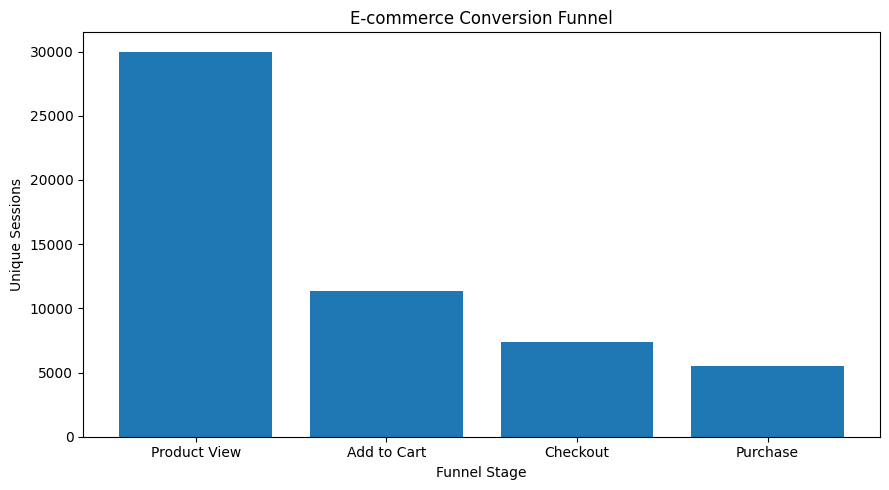

In [24]:
plt.figure(figsize=(9, 5))

plt.bar(
    funnel_summary["Stage"],
    funnel_summary["Sessions"]
)

plt.title("E-commerce Conversion Funnel")
plt.xlabel("Funnel Stage")
plt.ylabel("Unique Sessions")

plt.tight_layout()
plt.show()

## 7. Conversion Trend & Anomaly Detection

After establishing the overall baseline, performance is evaluated over time.

The key question is:

> **Is conversion performance stable, or has customer progression through the funnel changed materially over time?**

A meaningful decline would require further decomposition to determine whether the issue is broad-based or concentrated within specific segments.

In [25]:
monthly_performance = (
    session_df
    .groupby("month", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        cart_sessions=("add_to_cart", "sum"),
        checkout_sessions=("checkout", "sum"),
        purchase_sessions=("purchase", "sum")
    )
)

monthly_performance["cart_rate"] = (
    monthly_performance["cart_sessions"]
    / monthly_performance["sessions"] * 100
)

monthly_performance["checkout_rate"] = (
    monthly_performance["checkout_sessions"]
    / monthly_performance["sessions"] * 100
)

monthly_performance["conversion_rate"] = (
    monthly_performance["purchase_sessions"]
    / monthly_performance["sessions"] * 100
)

monthly_performance.round(2)

,month,sessions,cart_sessions,checkout_sessions,purchase_sessions,cart_rate,checkout_rate,conversion_rate
0,2026-01,5123,1935,1293,974,37.77,25.24,19.01
1,2026-02,4666,1786,1179,891,38.28,25.27,19.10
2,2026-03,5152,1938,1269,936,37.62,24.63,18.17
3,2026-04,4869,1843,1216,926,37.85,24.97,19.02
4,2026-05,5265,1971,1290,954,37.44,24.50,18.12
5,2026-06,4925,1851,1147,801,37.58,23.29,16.26


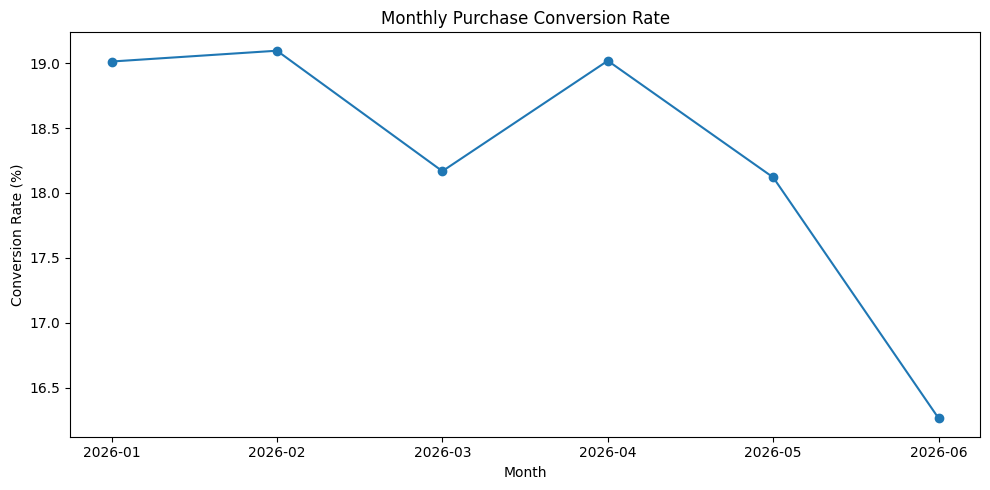

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_performance["month"],
    monthly_performance["conversion_rate"],
    marker="o"
)

plt.title("Monthly Purchase Conversion Rate")
plt.xlabel("Month")
plt.ylabel("Conversion Rate (%)")

plt.tight_layout()
plt.show()

### Increasing the Time Granularity

Monthly performance can hide changes that begin partway through a month.

The analysis therefore moves to weekly granularity to identify more precisely when conversion behavior begins to change.

In [27]:
weekly_performance = (
    session_df
    .groupby("week", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        cart_sessions=("add_to_cart", "sum"),
        checkout_sessions=("checkout", "sum"),
        purchase_sessions=("purchase", "sum")
    )
)

weekly_performance["conversion_rate"] = (
    weekly_performance["purchase_sessions"]
    / weekly_performance["sessions"] * 100
)

weekly_performance["cart_rate"] = (
    weekly_performance["cart_sessions"]
    / weekly_performance["sessions"] * 100
)

weekly_performance["checkout_rate"] = (
    weekly_performance["checkout_sessions"]
    / weekly_performance["sessions"] * 100
)

weekly_performance.round(2)

,week,sessions,cart_sessions,checkout_sessions,purchase_sessions,conversion_rate,cart_rate,checkout_rate
0,2025-12-29/2026-01-04,654,251,171,129,19.72,38.38,26.15
1,2026-01-05/2026-01-11,1178,433,285,220,18.68,36.76,24.19
2,2026-01-12/2026-01-18,1128,417,284,218,19.33,36.97,25.18
3,2026-01-19/2026-01-25,1156,442,304,232,20.07,38.24,26.30
4,2026-01-26/2026-02-01,1189,476,310,218,18.33,40.03,26.07
5,2026-02-02/2026-02-08,1095,414,272,210,19.18,37.81,24.84
6,2026-02-09/2026-02-15,1231,445,280,200,16.25,36.15,22.75
7,2026-02-16/2026-02-22,1147,455,309,240,20.92,39.67,26.94
8,2026-02-23/2026-03-01,1164,441,288,225,19.33,37.89,24.74
9,2026-03-02/2026-03-08,1160,410,278,189,16.29,35.34,23.97


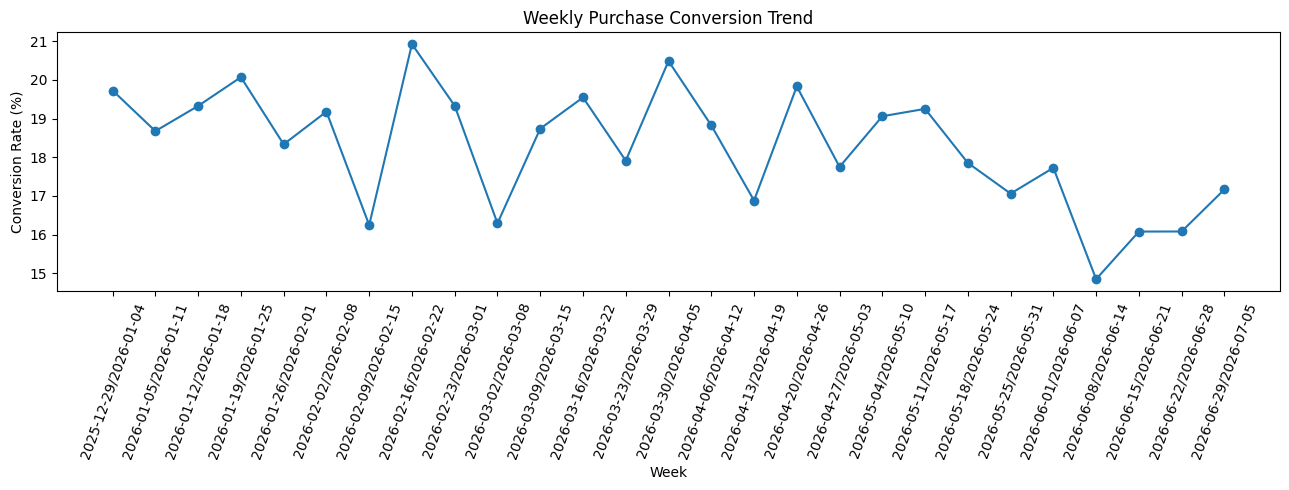

In [28]:
plt.figure(figsize=(13, 5))

plt.plot(
    weekly_performance["week"],
    weekly_performance["conversion_rate"],
    marker="o"
)

plt.title("Weekly Purchase Conversion Trend")
plt.xlabel("Week")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=70)

plt.tight_layout()
plt.show()

## 8. Funnel Decomposition

A decline in final conversion can originate from different parts of the customer journey.

For example:

- fewer users may add products to cart,
- cart users may fail to initiate checkout, or
- checkout users may fail to complete payment.

To identify the source of the change, stage-to-stage conversion is analyzed separately.

In [29]:
weekly_funnel = weekly_performance.copy()

weekly_funnel["view_to_cart"] = (
    weekly_funnel["cart_sessions"]
    / weekly_funnel["sessions"] * 100
)

weekly_funnel["cart_to_checkout"] = (
    weekly_funnel["checkout_sessions"]
    / weekly_funnel["cart_sessions"] * 100
)

weekly_funnel["checkout_to_purchase"] = (
    weekly_funnel["purchase_sessions"]
    / weekly_funnel["checkout_sessions"] * 100
)

weekly_funnel[
    [
        "week",
        "view_to_cart",
        "cart_to_checkout",
        "checkout_to_purchase"
    ]
].round(2)

,week,view_to_cart,cart_to_checkout,checkout_to_purchase
0,2025-12-29/2026-01-04,38.38,68.13,75.44
1,2026-01-05/2026-01-11,36.76,65.82,77.19
2,2026-01-12/2026-01-18,36.97,68.11,76.76
3,2026-01-19/2026-01-25,38.24,68.78,76.32
4,2026-01-26/2026-02-01,40.03,65.13,70.32
5,2026-02-02/2026-02-08,37.81,65.70,77.21
6,2026-02-09/2026-02-15,36.15,62.92,71.43
7,2026-02-16/2026-02-22,39.67,67.91,77.67
8,2026-02-23/2026-03-01,37.89,65.31,78.12
9,2026-03-02/2026-03-08,35.34,67.80,67.99


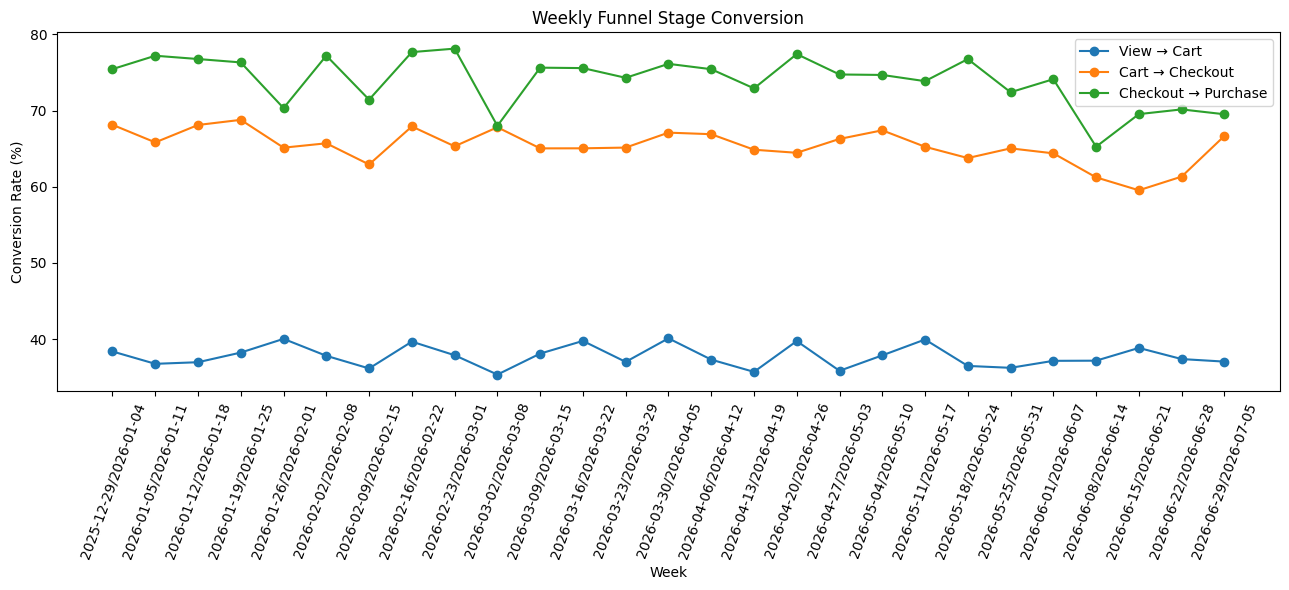

In [30]:
plt.figure(figsize=(13, 6))

plt.plot(
    weekly_funnel["week"],
    weekly_funnel["view_to_cart"],
    marker="o",
    label="View → Cart"
)

plt.plot(
    weekly_funnel["week"],
    weekly_funnel["cart_to_checkout"],
    marker="o",
    label="Cart → Checkout"
)

plt.plot(
    weekly_funnel["week"],
    weekly_funnel["checkout_to_purchase"],
    marker="o",
    label="Checkout → Purchase"
)

plt.title("Weekly Funnel Stage Conversion")
plt.xlabel("Week")
plt.ylabel("Conversion Rate (%)")

plt.xticks(rotation=70)
plt.legend()

plt.tight_layout()
plt.show()

## 9. Segment-Level Diagnostic Analysis

If overall conversion changes, the next objective is to determine whether the decline is:

1. **Broad-based** — affecting most customers and traffic sources, or
2. **Concentrated** — driven by a particular device, acquisition channel, category, customer type, or combination of segments.

The investigation therefore decomposes conversion across the major business dimensions before moving into deeper interaction analysis.

In [31]:
device_performance = (
    session_df
    .groupby("device", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

device_performance["conversion_rate"] = (
    device_performance["purchases"]
    / device_performance["sessions"] * 100
)

device_performance.sort_values(
    "conversion_rate",
    ascending=False
).round(2)

,device,sessions,purchases,conversion_rate
0,Desktop,7462,1494,20.02
2,Tablet,2104,374,17.78
1,Mobile,20434,3614,17.69


In [32]:
channel_performance = (
    session_df
    .groupby("acquisition_channel", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

channel_performance["conversion_rate"] = (
    channel_performance["purchases"]
    / channel_performance["sessions"] * 100
)

channel_performance.sort_values(
    "conversion_rate",
    ascending=False
).round(2)

,acquisition_channel,sessions,purchases,conversion_rate
2,Email,2728,633,23.20
1,Direct,4794,909,18.96
3,Organic Search,8372,1575,18.81
0,Affiliate,2138,399,18.66
4,Paid Search,6524,1113,17.06
5,Social,5388,853,15.83
6,Unknown,56,0,0.00


In [33]:
customer_type_performance = (
    session_df
    .groupby("customer_type", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

customer_type_performance["conversion_rate"] = (
    customer_type_performance["purchases"]
    / customer_type_performance["sessions"] * 100
)

customer_type_performance.round(2)

,customer_type,sessions,purchases,conversion_rate
0,New,17330,2795,16.13
1,Returning,12670,2687,21.21


In [34]:
category_performance = (
    session_df
    .groupby("category", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

category_performance["conversion_rate"] = (
    category_performance["purchases"]
    / category_performance["sessions"] * 100
)

category_performance.sort_values(
    "conversion_rate",
    ascending=False
).round(2)

,category,sessions,purchases,conversion_rate
2,Footwear,4898,926,18.91
3,Home & Living,5009,934,18.65
4,Men Fashion,5000,926,18.52
1,Beauty,5035,915,18.17
5,Women Fashion,4940,877,17.75
0,Accessories,5118,904,17.66


## 10. Root-Cause Analysis

The baseline analysis identifies a meaningful deterioration in conversion toward the end of the observation period.

Monthly purchase conversion declined to **16.26% in June**, compared with approximately **18–19% during most earlier months**.

The funnel decomposition also suggests that the decline is not primarily occurring at product discovery. View-to-cart performance remains relatively stable, while deterioration becomes more visible deeper in the funnel, particularly around checkout progression and purchase completion.

### Diagnostic Hypothesis

The next analysis tests whether the decline is:

1. concentrated within a particular device,
2. concentrated within a specific acquisition channel,
3. amplified by a device × channel interaction,
4. associated with particular product categories or customer segments, or
5. caused partly by a change in traffic mix rather than underlying funnel performance.

No root cause is assumed at this stage. Each hypothesis will be tested systematically.

### Pre/Post Diagnostic Window

To isolate the late-period deterioration, sessions are divided into:

- **Baseline Period:** Before 15 May 2026
- **Diagnostic Period:** 15 May 2026 onward

This split enables direct comparison of segment-level conversion before and during the observed deterioration.

In [35]:
session_df["analysis_period"] = np.where(
    session_df["session_start"] < pd.Timestamp("2026-05-15"),
    "Baseline",
    "Diagnostic"
)

session_df["analysis_period"].value_counts().to_frame("sessions")

,sessions
analysis_period,
Baseline,22230
Diagnostic,7770


### Hypothesis 1 — Is the decline concentrated by device?

Overall device performance shows Desktop converting above Mobile and Tablet.

However, aggregate performance alone cannot establish whether a device caused the recent decline. Conversion must therefore be compared across the baseline and diagnostic periods.

In [36]:
device_period = (
    session_df
    .groupby(["device", "analysis_period"], as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

device_period["conversion_rate"] = (
    device_period["purchases"]
    / device_period["sessions"] * 100
)

device_period.round(2)

,device,analysis_period,sessions,purchases,conversion_rate
0,Desktop,Baseline,5545,1123,20.25
1,Desktop,Diagnostic,1917,371,19.35
2,Mobile,Baseline,15153,2792,18.43
3,Mobile,Diagnostic,5281,822,15.57
4,Tablet,Baseline,1532,261,17.04
5,Tablet,Diagnostic,572,113,19.76


In [37]:
device_change = (
    device_period
    .pivot(
        index="device",
        columns="analysis_period",
        values="conversion_rate"
    )
)

device_change["Change (pp)"] = (
    device_change["Diagnostic"]
    - device_change["Baseline"]
)

device_change.round(2).sort_values("Change (pp)")

analysis_period,Baseline,Diagnostic,Change (pp)
device,,,
Mobile,18.43,15.57,-2.86
Desktop,20.25,19.35,-0.90
Tablet,17.04,19.76,2.72


### Hypothesis 2 — Is the decline concentrated by acquisition channel?

Acquisition channels attract customers with different intent levels, so their overall conversion rates naturally differ.

The relevant question is therefore not simply which channel has the lowest conversion, but **which channel experienced the largest deterioration relative to its own baseline**.

In [38]:
channel_period = (
    session_df
    .query("acquisition_channel != 'Unknown'")
    .groupby(
        ["acquisition_channel", "analysis_period"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

channel_period["conversion_rate"] = (
    channel_period["purchases"]
    / channel_period["sessions"] * 100
)

channel_change = (
    channel_period
    .pivot(
        index="acquisition_channel",
        columns="analysis_period",
        values="conversion_rate"
    )
)

channel_change["Change (pp)"] = (
    channel_change["Diagnostic"]
    - channel_change["Baseline"]
)

channel_change.round(2).sort_values("Change (pp)")

analysis_period,Baseline,Diagnostic,Change (pp)
acquisition_channel,,,
Paid Search,18.65,12.57,-6.08
Organic Search,19.31,17.35,-1.96
Email,23.58,22.16,-1.42
Direct,19.09,18.60,-0.49
Affiliate,18.66,18.67,0.01
Social,15.70,16.20,0.49


### Hypothesis 3 — Is the issue hidden inside a device × channel interaction?

A channel may appear healthy overall while performing poorly on one device, and a device may appear weak because of one disproportionately affected traffic source.

Device and acquisition channel are therefore analyzed together to identify whether the deterioration is concentrated within a specific customer journey.

In [39]:
device_channel_period = (
    session_df
    .query("acquisition_channel != 'Unknown'")
    .groupby(
        ["device", "acquisition_channel", "analysis_period"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

device_channel_period["conversion_rate"] = (
    device_channel_period["purchases"]
    / device_channel_period["sessions"] * 100
)

device_channel_change = (
    device_channel_period
    .pivot_table(
        index=["device", "acquisition_channel"],
        columns="analysis_period",
        values=["sessions", "conversion_rate"]
    )
)

device_channel_change.columns = [
    f"{metric}_{period}"
    for metric, period in device_channel_change.columns
]

device_channel_change = device_channel_change.reset_index()

In [40]:
device_channel_change["Conversion Change (pp)"] = (
    device_channel_change["conversion_rate_Diagnostic"]
    - device_channel_change["conversion_rate_Baseline"]
)

device_channel_change[
    [
        "device",
        "acquisition_channel",
        "sessions_Baseline",
        "sessions_Diagnostic",
        "conversion_rate_Baseline",
        "conversion_rate_Diagnostic",
        "Conversion Change (pp)"
    ]
].sort_values("Conversion Change (pp)").round(2)

,device,acquisition_channel,sessions_Baseline,sessions_Diagnostic,conversion_rate_Baseline,conversion_rate_Diagnostic,Conversion Change (pp)
10,Mobile,Paid Search,3281.0,1192.0,17.65,9.40,-8.25
2,Desktop,Email,530.0,185.0,29.06,22.16,-6.89
13,Tablet,Direct,257.0,88.0,17.51,13.64,-3.87
9,Mobile,Organic Search,4259.0,1441.0,19.63,16.86,-2.77
6,Mobile,Affiliate,1106.0,356.0,18.81,16.57,-2.23
16,Tablet,Paid Search,361.0,119.0,19.39,17.65,-1.74
3,Desktop,Organic Search,1561.0,540.0,19.22,17.78,-1.44
4,Desktop,Paid Search,1172.0,399.0,21.25,20.55,-0.69
1,Desktop,Direct,879.0,288.0,20.93,20.49,-0.45
8,Mobile,Email,1340.0,478.0,21.64,21.34,-0.30


In [41]:
segment_funnel = (
    session_df
    .query("acquisition_channel != 'Unknown'")
    .groupby(
        ["device", "acquisition_channel", "analysis_period"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        carts=("add_to_cart", "sum"),
        checkouts=("checkout", "sum"),
        purchases=("purchase", "sum")
    )
)

segment_funnel["view_to_cart"] = (
    segment_funnel["carts"]
    / segment_funnel["sessions"] * 100
)

segment_funnel["cart_to_checkout"] = (
    segment_funnel["checkouts"]
    / segment_funnel["carts"] * 100
)

segment_funnel["checkout_to_purchase"] = (
    segment_funnel["purchases"]
    / segment_funnel["checkouts"] * 100
)

segment_funnel.round(2)

,device,acquisition_channel,analysis_period,sessions,carts,checkouts,purchases,view_to_cart,cart_to_checkout,checkout_to_purchase
0,Desktop,Affiliate,Baseline,395,146,96,74,36.96,65.75,77.08
1,Desktop,Affiliate,Diagnostic,136,52,35,28,38.24,67.31,80.00
2,Desktop,Direct,Baseline,879,353,231,184,40.16,65.44,79.65
3,Desktop,Direct,Diagnostic,288,104,72,59,36.11,69.23,81.94
4,Desktop,Email,Baseline,530,261,180,154,49.25,68.97,85.56
5,Desktop,Email,Diagnostic,185,78,46,41,42.16,58.97,89.13
6,Desktop,Organic Search,Baseline,1561,611,391,300,39.14,63.99,76.73
7,Desktop,Organic Search,Diagnostic,540,215,134,96,39.81,62.33,71.64
8,Desktop,Paid Search,Baseline,1172,482,323,249,41.13,67.01,77.09
9,Desktop,Paid Search,Diagnostic,399,148,99,82,37.09,66.89,82.83


In [42]:
worst_segment = (
    device_channel_change
    .sort_values("Conversion Change (pp)")
    .iloc[0]
)

worst_device = worst_segment["device"]
worst_channel = worst_segment["acquisition_channel"]

worst_segment_funnel = (
    segment_funnel
    .loc[
        segment_funnel["device"].eq(worst_device)
        & segment_funnel["acquisition_channel"].eq(worst_channel)
    ]
    [
        [
            "analysis_period",
            "sessions",
            "view_to_cart",
            "cart_to_checkout",
            "checkout_to_purchase"
        ]
    ]
)

worst_segment_funnel.round(2)

,analysis_period,sessions,view_to_cart,cart_to_checkout,checkout_to_purchase
20,Baseline,3281,36.06,65.77,74.42
21,Diagnostic,1192,36.16,51.74,50.22


### Hypothesis 4 — Is the affected journey concentrated within a product category?

Overall category conversion rates are relatively close, which does not immediately suggest a broad category problem.

However, an issue may still be concentrated within a category **inside the affected device-channel journey**. The next analysis tests this interaction.

In [43]:
affected_category = (
    session_df
    .loc[
        session_df["device"].eq(worst_device)
        & session_df["acquisition_channel"].eq(worst_channel)
    ]
    .groupby(
        ["category", "analysis_period"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

affected_category["conversion_rate"] = (
    affected_category["purchases"]
    / affected_category["sessions"] * 100
)

category_change = (
    affected_category
    .pivot(
        index="category",
        columns="analysis_period",
        values="conversion_rate"
    )
)

category_change["Change (pp)"] = (
    category_change["Diagnostic"]
    - category_change["Baseline"]
)

category_change.round(2).sort_values("Change (pp)")

analysis_period,Baseline,Diagnostic,Change (pp)
category,,,
Beauty,19.68,8.63,-11.05
Women Fashion,18.57,8.06,-10.52
Footwear,16.98,7.69,-9.29
Home & Living,17.70,9.95,-7.75
Accessories,15.87,9.27,-6.60
Men Fashion,17.06,12.33,-4.73


In [44]:
customer_period = (
    session_df
    .groupby(
        ["customer_type", "analysis_period"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

customer_period["conversion_rate"] = (
    customer_period["purchases"]
    / customer_period["sessions"] * 100
)

customer_change = (
    customer_period
    .pivot(
        index="customer_type",
        columns="analysis_period",
        values="conversion_rate"
    )
)

customer_change["Change (pp)"] = (
    customer_change["Diagnostic"]
    - customer_change["Baseline"]
)

customer_change.round(2)

analysis_period,Baseline,Diagnostic,Change (pp)
customer_type,,,
New,16.68,14.54,-2.13
Returning,21.69,19.86,-1.83


## 11. Traffic Mix vs Conversion Performance

An overall conversion decline can occur for two fundamentally different reasons:

- **Mix Effect:** A larger share of traffic shifts toward naturally lower-converting segments.
- **Performance Effect:** The same segment converts worse than it did previously.

Distinguishing these effects is important because the business response would be different. A traffic-mix problem may require acquisition optimization, while a within-segment performance problem may indicate funnel, UX, checkout or operational friction.

In [45]:
channel_mix = (
    session_df
    .query("acquisition_channel != 'Unknown'")
    .groupby(
        ["analysis_period", "acquisition_channel"],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique")
    )
)

channel_mix["traffic_share_pct"] = (
    channel_mix["sessions"]
    / channel_mix.groupby("analysis_period")["sessions"].transform("sum")
    * 100
)

channel_mix_pivot = (
    channel_mix
    .pivot(
        index="acquisition_channel",
        columns="analysis_period",
        values="traffic_share_pct"
    )
)

channel_mix_pivot["Share Change (pp)"] = (
    channel_mix_pivot["Diagnostic"]
    - channel_mix_pivot["Baseline"]
)

channel_mix_pivot.round(2).sort_values(
    "Share Change (pp)",
    ascending=False
)

analysis_period,Baseline,Diagnostic,Share Change (pp)
acquisition_channel,,,
Paid Search,21.70,22.04,0.34
Direct,15.94,16.22,0.28
Email,9.04,9.31,0.26
Social,18.02,17.90,-0.12
Affiliate,7.20,6.97,-0.22
Organic Search,28.10,27.56,-0.54


## 12. Commercial Impact Estimation

After isolating the affected segment, the analysis estimates the commercial significance of the deterioration.

A baseline conversion rate is applied to diagnostic-period traffic to estimate how many purchases might have occurred if the segment had maintained its earlier performance.

This is a scenario-based impact estimate rather than a causal forecast.

In [46]:
affected_segment = session_df.loc[
    session_df["device"].eq(worst_device)
    & session_df["acquisition_channel"].eq(worst_channel)
].copy()

impact_summary = (
    affected_segment
    .groupby("analysis_period")
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

impact_summary["conversion_rate"] = (
    impact_summary["purchases"]
    / impact_summary["sessions"]
)

impact_summary

,sessions,purchases,conversion_rate
analysis_period,,,
Baseline,3281,579,0.176471
Diagnostic,1192,112,0.093960


In [47]:
baseline_rate = impact_summary.loc[
    "Baseline",
    "conversion_rate"
]

diagnostic_sessions = impact_summary.loc[
    "Diagnostic",
    "sessions"
]

actual_purchases = impact_summary.loc[
    "Diagnostic",
    "purchases"
]

expected_purchases = diagnostic_sessions * baseline_rate

estimated_lost_purchases = max(
    expected_purchases - actual_purchases,
    0
)

overall_aov = gmv / orders

estimated_revenue_impact = (
    estimated_lost_purchases * overall_aov
)

commercial_impact = pd.DataFrame({
    "Metric": [
        "Affected Device",
        "Affected Channel",
        "Baseline Conversion (%)",
        "Diagnostic Sessions",
        "Actual Purchases",
        "Expected Purchases at Baseline",
        "Estimated Lost Purchases",
        "Overall AOV",
        "Estimated Revenue Impact"
    ],
    "Value": [
        worst_device,
        worst_channel,
        round(baseline_rate * 100, 2),
        diagnostic_sessions,
        actual_purchases,
        round(expected_purchases, 1),
        round(estimated_lost_purchases, 1),
        round(overall_aov, 2),
        round(estimated_revenue_impact, 2)
    ]
})

commercial_impact

,Metric,Value
0,Affected Device,Mobile
1,Affected Channel,Paid Search
2,Baseline Conversion (%),17.65
3,Diagnostic Sessions,1192
4,Actual Purchases,112
5,Expected Purchases at Baseline,210.4
6,Estimated Lost Purchases,98.4
7,Overall AOV,2788.55
8,Estimated Revenue Impact,274261.91


## 13. Executive Root-Cause Summary

The diagnostic analysis is consolidated into an executive-level summary.

Rather than selecting the lowest-performing segment based on overall conversion, the analysis identifies the segment experiencing the largest deterioration relative to its own historical baseline.

This distinction separates a structurally low-converting segment from a segment that has recently developed a performance problem.

In [48]:
root_cause_summary = pd.DataFrame({
    "Finding": [
        "Largest Deterioration - Device",
        "Largest Deterioration - Channel",
        "Most Affected Device × Channel",
        "Baseline Conversion (%)",
        "Diagnostic Conversion (%)",
        "Conversion Change (pp)",
        "Estimated Lost Purchases",
        "Estimated Revenue Impact"
    ],
    "Result": [
        device_change["Change (pp)"].idxmin(),
        channel_change["Change (pp)"].idxmin(),
        f"{worst_device} × {worst_channel}",
        round(
            worst_segment["conversion_rate_Baseline"], 2
        ),
        round(
            worst_segment["conversion_rate_Diagnostic"], 2
        ),
        round(
            worst_segment["Conversion Change (pp)"], 2
        ),
        round(estimated_lost_purchases, 1),
        round(estimated_revenue_impact, 2)
    ]
})

root_cause_summary

,Finding,Result
0,Largest Deterioration - Device,Mobile
1,Largest Deterioration - Channel,Paid Search
2,Most Affected Device × Channel,Mobile × Paid Search
3,Baseline Conversion (%),17.65
4,Diagnostic Conversion (%),9.4
5,Conversion Change (pp),-8.25
6,Estimated Lost Purchases,98.4
7,Estimated Revenue Impact,274261.91


In [49]:
funnel_compare = (
    worst_segment_funnel
    .set_index("analysis_period")
    [
        [
            "view_to_cart",
            "cart_to_checkout",
            "checkout_to_purchase"
        ]
    ]
    .T
)

funnel_compare["Change (pp)"] = (
    funnel_compare["Diagnostic"]
    - funnel_compare["Baseline"]
)

funnel_compare = (
    funnel_compare
    .sort_values("Change (pp)")
)

funnel_compare.round(2)

analysis_period,Baseline,Diagnostic,Change (pp)
checkout_to_purchase,74.42,50.22,-24.20
cart_to_checkout,65.77,51.74,-14.02
view_to_cart,36.06,36.16,0.10


In [50]:
primary_friction_stage = funnel_compare.index[0]

stage_labels = {
    "view_to_cart": "Product View → Add to Cart",
    "cart_to_checkout": "Add to Cart → Checkout",
    "checkout_to_purchase": "Checkout → Purchase"
}

primary_friction = stage_labels[primary_friction_stage]

pd.DataFrame({
    "Diagnostic Result": [
        "Primary Funnel Friction",
        "Stage Conversion Change (pp)"
    ],
    "Value": [
        primary_friction,
        round(
            funnel_compare.iloc[0]["Change (pp)"],
            2
        )
    ]
})

,Diagnostic Result,Value
0,Primary Funnel Friction,Checkout → Purchase
1,Stage Conversion Change (pp),-24.2


In [51]:
most_affected_category = category_change["Change (pp)"].idxmin()

category_diagnostic = pd.DataFrame({
    "Metric": [
        "Most Affected Category",
        "Baseline Conversion (%)",
        "Diagnostic Conversion (%)",
        "Change (pp)"
    ],
    "Value": [
        most_affected_category,
        round(
            category_change.loc[
                most_affected_category,
                "Baseline"
            ], 2
        ),
        round(
            category_change.loc[
                most_affected_category,
                "Diagnostic"
            ], 2
        ),
        round(
            category_change.loc[
                most_affected_category,
                "Change (pp)"
            ], 2
        )
    ]
})

category_diagnostic

,Metric,Value
0,Most Affected Category,Beauty
1,Baseline Conversion (%),19.68
2,Diagnostic Conversion (%),8.63
3,Change (pp),-11.05


In [52]:
final_findings = pd.DataFrame({
    "Area": [
        "Overall Performance",
        "Primary Segment",
        "Primary Funnel Friction",
        "Secondary Category Signal",
        "Customer Behaviour",
        "Commercial Impact"
    ],
    "Finding": [
        "Conversion weakened materially toward the end of the analysis period.",

        f"The largest relative deterioration was concentrated in "
        f"{worst_device} traffic acquired through {worst_channel}.",

        f"The strongest funnel deterioration within the affected segment "
        f"occurred at {primary_friction}.",

        f"{most_affected_category} showed the largest category-level "
        f"deterioration within the affected journey.",

        "Returning customers maintained materially stronger conversion "
        "than new customers overall.",

        f"Maintaining baseline conversion in the affected segment would "
        f"have implied approximately {estimated_lost_purchases:.0f} "
        f"additional purchases, representing an estimated revenue "
        f"opportunity of about {estimated_revenue_impact:,.0f}."
    ]
})

final_findings

,Area,Finding
0,Overall Performance,Conversion weakened materially toward the end ...
1,Primary Segment,The largest relative deterioration was concent...
2,Primary Funnel Friction,The strongest funnel deterioration within the ...
3,Secondary Category Signal,Beauty showed the largest category-level deter...
4,Customer Behaviour,Returning customers maintained materially stro...
5,Commercial Impact,Maintaining baseline conversion in the affecte...


## 14. Business Recommendations

The analysis supports a targeted response rather than a broad redesign of the entire customer journey.

### 1. Investigate the affected device-channel journey

Prioritize technical and UX investigation of the segment showing the largest deterioration relative to its historical baseline.

Review:

- landing-page experience,
- page-load performance,
- campaign-to-product relevance,
- cart progression,
- checkout errors,
- payment failures, and
- recent product or campaign changes.

### 2. Prioritize the identified funnel friction

The stage showing the largest deterioration should receive the highest diagnostic priority.

This avoids treating the entire conversion funnel as equally problematic.

### 3. Investigate category-specific interaction effects

The most affected category within the problematic journey should be reviewed separately for:

- pricing,
- discount presentation,
- stock availability,
- delivery expectations,
- product-page experience, and
- checkout completion.

### 4. Protect high-intent returning customers

Returning customers demonstrate stronger purchase conversion than new customers.

Retention and remarketing strategies should therefore preserve the experience of existing customers while acquisition teams investigate lower-performing new-user journeys.

### 5. Introduce segmented conversion monitoring

A single overall conversion KPI can hide concentrated problems.

Future monitoring should track conversion by:

- Device
- Acquisition Channel
- Device × Channel
- Customer Type
- Category
- Funnel Stage

### 6. Add automated anomaly alerts

Trigger investigation when a high-volume segment experiences a material week-over-week conversion decline.

This would allow the business to detect localized funnel problems before they significantly affect revenue.

In [53]:
final_session_df = session_df.copy()

final_session_df.head()

,session_id,customer_id,customer_type,session_start,product_id,product_name,category,device,acquisition_channel,city,discount_pct,add_to_cart,checkout,product_view,purchase,date,month,week,day_of_week,analysis_period
0,S000001,C01174,Returning,2026-02-05 12:42:30,P1120,Towel 4,Home & Living,Mobile,Direct,Bengaluru,10,1,1,1,1,2026-02-05,2026-02,2026-02-02/2026-02-08,Thursday,Baseline
1,S000002,C17172,Returning,2026-05-15 19:13:24,P1042,Sneakers 2,Footwear,Mobile,Paid Search,Bengaluru,10,1,1,1,1,2026-05-15,2026-05,2026-05-11/2026-05-17,Friday,Diagnostic
2,S000003,C02913,New,2026-06-30 05:21:55,P1033,Jacket 1,Men Fashion,Mobile,Paid Search,Ahmedabad,5,1,0,1,0,2026-06-30,2026-06,2026-06-29/2026-07-05,Tuesday,Diagnostic
3,S000004,C10416,New,2026-01-02 08:11:11,P1026,T-Shirt 2,Men Fashion,Desktop,Social,Bengaluru,15,0,0,1,0,2026-01-02,2026-01,2025-12-29/2026-01-04,Friday,Baseline
4,S000005,C09849,New,2026-06-07 03:01:51,P1048,Running Shoes 4,Footwear,Mobile,Direct,Delhi NCR,20,0,0,1,0,2026-06-07,2026-06,2026-06-01/2026-06-07,Sunday,Diagnostic


In [54]:
analysis_outputs = {
    "Executive_KPIs": executive_kpis,
    "Funnel_Summary": funnel_summary,
    "Monthly_Performance": monthly_performance,
    "Weekly_Performance": weekly_performance,
    "Device_Performance": device_performance,
    "Channel_Performance": channel_performance,
    "Customer_Performance": customer_type_performance,
    "Category_Performance": category_performance,
    "Root_Cause_Summary": root_cause_summary,
    "Funnel_RCA": funnel_compare.reset_index(),
    "Commercial_Impact": commercial_impact,
    "Final_Findings": final_findings
}

## 15. Analytical Deliverables

The validated event-level dataset and derived session-level analytical table are exported separately.

This preserves two useful levels of granularity:

- **Event Level:** Detailed customer interactions for audit and funnel reconstruction.
- **Session Level:** Business-ready analytical dataset for conversion and segmentation analysis.

In [55]:
clean_df.to_csv(
    "clean_ecommerce_events.csv",
    index=False
)

final_session_df.to_csv(
    "ecommerce_session_analytics.csv",
    index=False
)

In [56]:
excel_file = "Ecommerce_Conversion_Growth_Analysis.xlsx"

with pd.ExcelWriter(
    excel_file,
    engine="openpyxl"
) as writer:

    executive_kpis.to_excel(
        writer,
        sheet_name="Executive KPIs",
        index=False
    )

    funnel_summary.to_excel(
        writer,
        sheet_name="Conversion Funnel",
        index=False
    )

    monthly_performance.to_excel(
        writer,
        sheet_name="Monthly Trends",
        index=False
    )

    weekly_performance.to_excel(
        writer,
        sheet_name="Weekly Trends",
        index=False
    )

    device_performance.to_excel(
        writer,
        sheet_name="Device Analysis",
        index=False
    )

    channel_performance.to_excel(
        writer,
        sheet_name="Channel Analysis",
        index=False
    )

    category_performance.to_excel(
        writer,
        sheet_name="Category Analysis",
        index=False
    )

    root_cause_summary.to_excel(
        writer,
        sheet_name="Root Cause",
        index=False
    )

    commercial_impact.to_excel(
        writer,
        sheet_name="Commercial Impact",
        index=False
    )

    final_findings.to_excel(
        writer,
        sheet_name="Business Findings",
        index=False
    )

In [57]:
from openpyxl import load_workbook
from openpyxl.styles import Font, Alignment

workbook = load_workbook(excel_file)

for sheet in workbook.worksheets:

    sheet.freeze_panes = "A2"
    sheet.auto_filter.ref = sheet.dimensions

    for cell in sheet[1]:
        cell.font = Font(bold=True)
        cell.alignment = Alignment(
            horizontal="center"
        )

    for column_cells in sheet.columns:
        max_length = max(
            len(str(cell.value))
            if cell.value is not None else 0
            for cell in column_cells
        )

        column_letter = column_cells[0].column_letter

        sheet.column_dimensions[
            column_letter
        ].width = min(max_length + 3, 45)

workbook.save(excel_file)

## 16. SQL Analysis Layer

The cleaned session-level dataset is loaded into SQLite to reproduce key business analyses using SQL.

This demonstrates that the analytical conclusions are not dependent on a single tool and can be translated into a structured query workflow.

In [58]:
import sqlite3

conn = sqlite3.connect(
    "ecommerce_conversion_analysis.db"
)

final_session_df.to_sql(
    "sessions",
    conn,
    if_exists="replace",
    index=False
)

purchase_df.to_sql(
    "purchases",
    conn,
    if_exists="replace",
    index=False
)

5482

In [59]:
query = """
SELECT
    COUNT(DISTINCT session_id) AS total_sessions,
    SUM(add_to_cart) AS cart_sessions,
    SUM(checkout) AS checkout_sessions,
    SUM(purchase) AS purchase_sessions,

    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate

FROM sessions;
"""

pd.read_sql_query(query, conn)

,total_sessions,cart_sessions,checkout_sessions,purchase_sessions,conversion_rate
0,30000,11324,7394,5482,18.27


In [60]:
query = """
WITH segment_performance AS (

    SELECT
        device,
        acquisition_channel,
        analysis_period,

        COUNT(DISTINCT session_id) AS sessions,

        SUM(purchase) AS purchases,

        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id) AS conversion_rate

    FROM sessions

    WHERE acquisition_channel <> 'Unknown'

    GROUP BY
        device,
        acquisition_channel,
        analysis_period
),

comparison AS (

    SELECT
        device,
        acquisition_channel,

        MAX(
            CASE
                WHEN analysis_period = 'Baseline'
                THEN conversion_rate
            END
        ) AS baseline_conversion,

        MAX(
            CASE
                WHEN analysis_period = 'Diagnostic'
                THEN conversion_rate
            END
        ) AS diagnostic_conversion

    FROM segment_performance

    GROUP BY
        device,
        acquisition_channel
)

SELECT
    *,
    ROUND(
        diagnostic_conversion
        - baseline_conversion,
        2
    ) AS conversion_change_pp

FROM comparison

ORDER BY conversion_change_pp;
"""

sql_root_cause = pd.read_sql_query(
    query,
    conn
)

sql_root_cause

,device,acquisition_channel,baseline_conversion,diagnostic_conversion,conversion_change_pp
0,Mobile,Paid Search,17.647059,9.395973,-8.25
1,Desktop,Email,29.056604,22.162162,-6.89
2,Tablet,Direct,17.509728,13.636364,-3.87
3,Mobile,Organic Search,19.629021,16.863289,-2.77
4,Mobile,Affiliate,18.806510,16.573034,-2.23
5,Tablet,Paid Search,19.390582,17.647059,-1.74
6,Desktop,Organic Search,19.218450,17.777778,-1.44
7,Desktop,Paid Search,21.245734,20.551378,-0.69
8,Desktop,Direct,20.932878,20.486111,-0.45
9,Mobile,Email,21.641791,21.338912,-0.30


In [61]:
query = """
SELECT
    customer_type,

    COUNT(DISTINCT session_id) AS sessions,

    SUM(purchase) AS purchases,

    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate

FROM sessions

GROUP BY customer_type

ORDER BY conversion_rate DESC;
"""

pd.read_sql_query(query, conn)

,customer_type,sessions,purchases,conversion_rate
0,Returning,12670,2687,21.21
1,New,17330,2795,16.13


In [62]:
query = """
SELECT
    month,

    COUNT(DISTINCT session_id) AS sessions,

    SUM(add_to_cart) AS cart_sessions,

    SUM(checkout) AS checkout_sessions,

    SUM(purchase) AS purchase_sessions,

    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate

FROM sessions

GROUP BY month

ORDER BY month;
"""

pd.read_sql_query(query, conn)

,month,sessions,cart_sessions,checkout_sessions,purchase_sessions,conversion_rate
0,2026-01,5123,1935,1293,974,19.01
1,2026-02,4666,1786,1179,891,19.10
2,2026-03,5152,1938,1269,936,18.17
3,2026-04,4869,1843,1216,926,19.02
4,2026-05,5265,1971,1290,954,18.12
5,2026-06,4925,1851,1147,801,16.26


In [63]:
sql_script = """
-- E-commerce Product, Conversion Funnel & Growth Analytics


-- 1. Overall Conversion Funnel

SELECT
    COUNT(DISTINCT session_id) AS total_sessions,
    SUM(add_to_cart) AS cart_sessions,
    SUM(checkout) AS checkout_sessions,
    SUM(purchase) AS purchase_sessions,
    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate
FROM sessions;


-- 2. Conversion by Device

SELECT
    device,
    COUNT(DISTINCT session_id) AS sessions,
    SUM(purchase) AS purchases,
    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate
FROM sessions
GROUP BY device
ORDER BY conversion_rate DESC;


-- 3. Conversion by Acquisition Channel

SELECT
    acquisition_channel,
    COUNT(DISTINCT session_id) AS sessions,
    SUM(purchase) AS purchases,
    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate
FROM sessions
GROUP BY acquisition_channel
ORDER BY conversion_rate DESC;


-- 4. Monthly Conversion Trend

SELECT
    month,
    COUNT(DISTINCT session_id) AS sessions,
    SUM(purchase) AS purchases,
    ROUND(
        100.0 * SUM(purchase)
        / COUNT(DISTINCT session_id),
        2
    ) AS conversion_rate
FROM sessions
GROUP BY month
ORDER BY month;
"""

with open(
    "ecommerce_conversion_analysis.sql",
    "w"
) as file:
    file.write(sql_script)

## 17. Interactive Diagnostic Application

The final analytical layer is an interactive Streamlit application designed for business users and hiring reviewers.

Rather than functioning as a static dashboard, the application allows users to investigate conversion performance across:

- Date
- Device
- Acquisition Channel
- Product Category
- Customer Type

The application follows the same diagnostic workflow used in the analysis:

**Executive KPIs → Funnel → Trend → Segment Comparison → Root-Cause Investigation → Business Interpretation**

This allows the underlying analytical reasoning to be explored interactively.

In [64]:
streamlit_df = final_session_df.copy()

streamlit_df["session_start"] = pd.to_datetime(
    streamlit_df["session_start"]
)

streamlit_df.to_csv(
    "streamlit_session_data.csv",
    index=False
)

streamlit_df.head()

,session_id,customer_id,customer_type,session_start,product_id,product_name,category,device,acquisition_channel,city,discount_pct,add_to_cart,checkout,product_view,purchase,date,month,week,day_of_week,analysis_period
0,S000001,C01174,Returning,2026-02-05 12:42:30,P1120,Towel 4,Home & Living,Mobile,Direct,Bengaluru,10,1,1,1,1,2026-02-05,2026-02,2026-02-02/2026-02-08,Thursday,Baseline
1,S000002,C17172,Returning,2026-05-15 19:13:24,P1042,Sneakers 2,Footwear,Mobile,Paid Search,Bengaluru,10,1,1,1,1,2026-05-15,2026-05,2026-05-11/2026-05-17,Friday,Diagnostic
2,S000003,C02913,New,2026-06-30 05:21:55,P1033,Jacket 1,Men Fashion,Mobile,Paid Search,Ahmedabad,5,1,0,1,0,2026-06-30,2026-06,2026-06-29/2026-07-05,Tuesday,Diagnostic
3,S000004,C10416,New,2026-01-02 08:11:11,P1026,T-Shirt 2,Men Fashion,Desktop,Social,Bengaluru,15,0,0,1,0,2026-01-02,2026-01,2025-12-29/2026-01-04,Friday,Baseline
4,S000005,C09849,New,2026-06-07 03:01:51,P1048,Running Shoes 4,Footwear,Mobile,Direct,Delhi NCR,20,0,0,1,0,2026-06-07,2026-06,2026-06-01/2026-06-07,Sunday,Diagnostic


In [65]:
!pip -q install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 87.1 MB/s eta 0:00:00


In [66]:
app_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import plotly.express as px


# --------------------------------------------------
# PAGE CONFIG
# --------------------------------------------------

st.set_page_config(
    page_title="E-commerce Conversion Diagnostic",
    page_icon="🛍️",
    layout="wide"
)


# --------------------------------------------------
# LOAD DATA
# --------------------------------------------------

@st.cache_data
def load_data():
    df = pd.read_csv("streamlit_session_data.csv")
    df["session_start"] = pd.to_datetime(df["session_start"])
    return df


df = load_data()


# --------------------------------------------------
# HEADER
# --------------------------------------------------

st.title("E-commerce Conversion & Growth Diagnostic")

st.caption(
    "Interactive product and funnel analytics case study | "
    "Session-level conversion analysis"
)

st.markdown(
    """
    This application investigates how customers progress from
    **Product View → Add to Cart → Checkout → Purchase**.

    Use the filters to identify where conversion changes,
    which customer segments are affected, and where deeper
    investigation may be required.
    """
)


# --------------------------------------------------
# SIDEBAR FILTERS
# --------------------------------------------------

st.sidebar.header("Analysis Filters")

min_date = df["session_start"].min().date()
max_date = df["session_start"].max().date()

date_range = st.sidebar.date_input(
    "Date Range",
    value=(min_date, max_date),
    min_value=min_date,
    max_value=max_date
)

selected_devices = st.sidebar.multiselect(
    "Device",
    sorted(df["device"].dropna().unique()),
    default=sorted(df["device"].dropna().unique())
)

selected_channels = st.sidebar.multiselect(
    "Acquisition Channel",
    sorted(df["acquisition_channel"].dropna().unique()),
    default=sorted(df["acquisition_channel"].dropna().unique())
)

selected_categories = st.sidebar.multiselect(
    "Category",
    sorted(df["category"].dropna().unique()),
    default=sorted(df["category"].dropna().unique())
)

selected_customer_types = st.sidebar.multiselect(
    "Customer Type",
    sorted(df["customer_type"].dropna().unique()),
    default=sorted(df["customer_type"].dropna().unique())
)


# --------------------------------------------------
# APPLY FILTERS
# --------------------------------------------------

filtered_df = df.copy()

if len(date_range) == 2:

    start_date = pd.Timestamp(date_range[0])
    end_date = pd.Timestamp(date_range[1]) + pd.Timedelta(days=1)

    filtered_df = filtered_df[
        (filtered_df["session_start"] >= start_date)
        & (filtered_df["session_start"] < end_date)
    ]


filtered_df = filtered_df[
    filtered_df["device"].isin(selected_devices)
    & filtered_df["acquisition_channel"].isin(selected_channels)
    & filtered_df["category"].isin(selected_categories)
    & filtered_df["customer_type"].isin(selected_customer_types)
]


if filtered_df.empty:
    st.warning(
        "No sessions match the selected filters. "
        "Adjust the filters to continue the analysis."
    )
    st.stop()


# --------------------------------------------------
# KPI CALCULATIONS
# --------------------------------------------------

total_sessions = filtered_df["session_id"].nunique()
cart_sessions = filtered_df["add_to_cart"].sum()
checkout_sessions = filtered_df["checkout"].sum()
purchase_sessions = filtered_df["purchase"].sum()

conversion_rate = (
    purchase_sessions / total_sessions * 100
    if total_sessions else 0
)

cart_rate = (
    cart_sessions / total_sessions * 100
    if total_sessions else 0
)

cart_to_checkout = (
    checkout_sessions / cart_sessions * 100
    if cart_sessions else 0
)

checkout_to_purchase = (
    purchase_sessions / checkout_sessions * 100
    if checkout_sessions else 0
)

cart_abandonment = (
    (1 - purchase_sessions / cart_sessions) * 100
    if cart_sessions else 0
)


# --------------------------------------------------
# EXECUTIVE OVERVIEW
# --------------------------------------------------

st.divider()

st.subheader("Executive Overview")

col1, col2, col3, col4 = st.columns(4)

col1.metric(
    "Sessions",
    f"{total_sessions:,}"
)

col2.metric(
    "Purchase Sessions",
    f"{purchase_sessions:,}"
)

col3.metric(
    "Conversion Rate",
    f"{conversion_rate:.2f}%"
)

col4.metric(
    "Cart Abandonment",
    f"{cart_abandonment:.2f}%"
)


# --------------------------------------------------
# FUNNEL
# --------------------------------------------------

st.divider()

st.subheader("Conversion Funnel")

funnel = pd.DataFrame({
    "Stage": [
        "Product View",
        "Add to Cart",
        "Checkout",
        "Purchase"
    ],
    "Sessions": [
        total_sessions,
        cart_sessions,
        checkout_sessions,
        purchase_sessions
    ]
})

funnel["% of Sessions"] = (
    funnel["Sessions"] / total_sessions * 100
).round(2)

fig_funnel = px.bar(
    funnel,
    x="Stage",
    y="Sessions",
    text="Sessions",
    title="Customer Journey Funnel"
)

fig_funnel.update_layout(
    xaxis_title="Funnel Stage",
    yaxis_title="Unique Sessions"
)

st.plotly_chart(
    fig_funnel,
    use_container_width=True
)


stage_metrics = pd.DataFrame({
    "Transition": [
        "View → Cart",
        "Cart → Checkout",
        "Checkout → Purchase"
    ],
    "Conversion Rate (%)": [
        cart_rate,
        cart_to_checkout,
        checkout_to_purchase
    ]
}).round(2)

st.dataframe(
    stage_metrics,
    use_container_width=True,
    hide_index=True
)


# --------------------------------------------------
# TREND ANALYSIS
# --------------------------------------------------

st.divider()

st.subheader("Conversion Trend")

trend_df = filtered_df.copy()

trend_df["week_start"] = (
    trend_df["session_start"]
    .dt.to_period("W")
    .apply(lambda x: x.start_time)
)

weekly = (
    trend_df
    .groupby("week_start", as_index=False)
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

weekly["conversion_rate"] = (
    weekly["purchases"]
    / weekly["sessions"] * 100
)

fig_trend = px.line(
    weekly,
    x="week_start",
    y="conversion_rate",
    markers=True,
    title="Weekly Purchase Conversion Rate"
)

fig_trend.update_layout(
    xaxis_title="Week",
    yaxis_title="Conversion Rate (%)"
)

st.plotly_chart(
    fig_trend,
    use_container_width=True
)


# --------------------------------------------------
# SEGMENT DIAGNOSTICS
# --------------------------------------------------

st.divider()

st.subheader("Segment Diagnostics")

st.markdown(
    """
    Overall conversion can hide concentrated performance problems.
    Compare conversion across key business dimensions below.
    """
)


def segment_performance(data, dimension):

    result = (
        data
        .groupby(dimension, as_index=False)
        .agg(
            sessions=("session_id", "nunique"),
            purchases=("purchase", "sum")
        )
    )

    result["conversion_rate"] = (
        result["purchases"]
        / result["sessions"] * 100
    )

    return result.sort_values(
        "conversion_rate",
        ascending=False
    )


tab1, tab2, tab3, tab4 = st.tabs(
    [
        "Device",
        "Acquisition Channel",
        "Category",
        "Customer Type"
    ]
)


with tab1:

    device_perf = segment_performance(
        filtered_df,
        "device"
    )

    fig = px.bar(
        device_perf,
        x="device",
        y="conversion_rate",
        text_auto=".2f",
        title="Conversion by Device"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.dataframe(
        device_perf.round(2),
        use_container_width=True,
        hide_index=True
    )


with tab2:

    channel_perf = segment_performance(
        filtered_df,
        "acquisition_channel"
    )

    fig = px.bar(
        channel_perf,
        x="acquisition_channel",
        y="conversion_rate",
        text_auto=".2f",
        title="Conversion by Acquisition Channel"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.dataframe(
        channel_perf.round(2),
        use_container_width=True,
        hide_index=True
    )


with tab3:

    category_perf = segment_performance(
        filtered_df,
        "category"
    )

    fig = px.bar(
        category_perf,
        x="category",
        y="conversion_rate",
        text_auto=".2f",
        title="Conversion by Category"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.dataframe(
        category_perf.round(2),
        use_container_width=True,
        hide_index=True
    )


with tab4:

    customer_perf = segment_performance(
        filtered_df,
        "customer_type"
    )

    fig = px.bar(
        customer_perf,
        x="customer_type",
        y="conversion_rate",
        text_auto=".2f",
        title="Conversion by Customer Type"
    )

    st.plotly_chart(
        fig,
        use_container_width=True
    )

    st.dataframe(
        customer_perf.round(2),
        use_container_width=True,
        hide_index=True
    )


# --------------------------------------------------
# ROOT CAUSE DIAGNOSTIC
# --------------------------------------------------

st.divider()

st.subheader("Root-Cause Diagnostic")

st.markdown(
    """
    This section compares segment performance before and after
    **15 May 2026** to identify which device-channel journey
    experienced the largest deterioration relative to its own baseline.
    """
)

diagnostic_df = filtered_df.copy()

diagnostic_df["analysis_period"] = np.where(
    diagnostic_df["session_start"]
    < pd.Timestamp("2026-05-15"),
    "Baseline",
    "Diagnostic"
)

interaction = (
    diagnostic_df[
        diagnostic_df["acquisition_channel"] != "Unknown"
    ]
    .groupby(
        [
            "device",
            "acquisition_channel",
            "analysis_period"
        ],
        as_index=False
    )
    .agg(
        sessions=("session_id", "nunique"),
        purchases=("purchase", "sum")
    )
)

interaction["conversion_rate"] = (
    interaction["purchases"]
    / interaction["sessions"] * 100
)

interaction_pivot = (
    interaction
    .pivot_table(
        index=[
            "device",
            "acquisition_channel"
        ],
        columns="analysis_period",
        values="conversion_rate"
    )
    .reset_index()
)


if (
    "Baseline" in interaction_pivot.columns
    and "Diagnostic" in interaction_pivot.columns
):

    interaction_pivot = interaction_pivot.dropna(
        subset=["Baseline", "Diagnostic"]
    )

    interaction_pivot["Change (pp)"] = (
        interaction_pivot["Diagnostic"]
        - interaction_pivot["Baseline"]
    )

    interaction_pivot = interaction_pivot.sort_values(
        "Change (pp)"
    )

    st.dataframe(
        interaction_pivot.round(2),
        use_container_width=True,
        hide_index=True
    )

    if not interaction_pivot.empty:

        worst = interaction_pivot.iloc[0]

        affected_device = worst["device"]
        affected_channel = worst["acquisition_channel"]

        st.error(
            f"Largest deterioration: "
            f"{affected_device} × {affected_channel} | "
            f"{worst['Baseline']:.2f}% → "
            f"{worst['Diagnostic']:.2f}% "
            f"({worst['Change (pp)']:.2f} pp)"
        )


        # ------------------------------------------
        # FUNNEL DIAGNOSIS OF WORST SEGMENT
        # ------------------------------------------

        affected = diagnostic_df[
            (diagnostic_df["device"] == affected_device)
            & (
                diagnostic_df["acquisition_channel"]
                == affected_channel
            )
        ]

        affected_funnel = (
            affected
            .groupby(
                "analysis_period",
                as_index=False
            )
            .agg(
                sessions=("session_id", "nunique"),
                carts=("add_to_cart", "sum"),
                checkouts=("checkout", "sum"),
                purchases=("purchase", "sum")
            )
        )

        affected_funnel["View → Cart"] = (
            affected_funnel["carts"]
            / affected_funnel["sessions"] * 100
        )

        affected_funnel["Cart → Checkout"] = (
            affected_funnel["checkouts"]
            / affected_funnel["carts"] * 100
        )

        affected_funnel["Checkout → Purchase"] = (
            affected_funnel["purchases"]
            / affected_funnel["checkouts"] * 100
        )


        funnel_long = affected_funnel.melt(
            id_vars="analysis_period",
            value_vars=[
                "View → Cart",
                "Cart → Checkout",
                "Checkout → Purchase"
            ],
            var_name="Funnel Stage",
            value_name="Conversion Rate"
        )

        fig_rca = px.bar(
            funnel_long,
            x="Funnel Stage",
            y="Conversion Rate",
            color="analysis_period",
            barmode="group",
            title=(
                f"Funnel Diagnosis: "
                f"{affected_device} × {affected_channel}"
            )
        )

        st.plotly_chart(
            fig_rca,
            use_container_width=True
        )


        # ------------------------------------------
        # COMMERCIAL IMPACT
        # ------------------------------------------

        impact = (
            affected
            .groupby("analysis_period")
            .agg(
                sessions=("session_id", "nunique"),
                purchases=("purchase", "sum")
            )
        )

        if (
            "Baseline" in impact.index
            and "Diagnostic" in impact.index
        ):

            baseline_rate = (
                impact.loc["Baseline", "purchases"]
                / impact.loc["Baseline", "sessions"]
            )

            diagnostic_sessions = impact.loc[
                "Diagnostic",
                "sessions"
            ]

            actual_purchases = impact.loc[
                "Diagnostic",
                "purchases"
            ]

            expected_purchases = (
                diagnostic_sessions
                * baseline_rate
            )

            estimated_lost = max(
                expected_purchases
                - actual_purchases,
                0
            )

            st.markdown(
                "### Business Impact Scenario"
            )

            c1, c2, c3 = st.columns(3)

            c1.metric(
                "Expected Purchases at Baseline",
                f"{expected_purchases:.0f}"
            )

            c2.metric(
                "Actual Purchases",
                f"{actual_purchases:.0f}"
            )

            c3.metric(
                "Estimated Purchase Gap",
                f"{estimated_lost:.0f}"
            )

            st.caption(
                "Scenario estimate based on maintaining the "
                "segment's historical baseline conversion rate. "
                "This should not be interpreted as a causal forecast."
            )

else:

    st.info(
        "The selected filters do not contain sufficient "
        "baseline and diagnostic-period observations for comparison."
    )


# --------------------------------------------------
# BUSINESS INTERPRETATION
# --------------------------------------------------

st.divider()

st.subheader("How to Use This Analysis")

st.markdown(
    """
    **1. Detect**
    Identify whether overall conversion is changing.

    **2. Decompose**
    Determine which funnel stage contributes to the change.

    **3. Segment**
    Compare devices, channels, categories and customer types.

    **4. Diagnose**
    Test interaction effects rather than assuming that the
    lowest-converting segment caused the decline.

    **5. Quantify**
    Estimate the potential commercial significance of the issue.

    **6. Act**
    Prioritize targeted UX, acquisition, checkout or operational
    investigation based on the evidence.
    """
)


# --------------------------------------------------
# FOOTER
# --------------------------------------------------

st.divider()

st.caption(
    "Portfolio case study by Disha Pramanick | "
    "Python • SQL • Excel • Streamlit"
)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

In [67]:
import os

project_files = pd.DataFrame({
    "File": [
        file
        for file in os.listdir()
        if file.endswith(
            (".py", ".csv", ".xlsx", ".sql", ".db")
        )
    ]
})

project_files

,File
0,ecommerce_conversion_analysis.db
1,ecommerce_product_conversion_events.csv
2,streamlit_session_data.csv
3,clean_ecommerce_events.csv
4,app.py
5,Ecommerce_Conversion_Growth_Analysis.xlsx
6,ecommerce_conversion_analysis.sql
7,ecommerce_session_analytics.csv


In [69]:
!streamlit run app.py --server.port 8501 &>/content/streamlit.log &

In [70]:
!curl -I http://localhost:8501

HTTP/1.1 200 OK
date: Thu, 01 Oct 2026 11:30:54 GMT
server: uvicorn
content-type: text/html; charset=utf-8
accept-ranges: bytes
content-length: 7260
last-modified: Thu, 01 Oct 2026 11:23:21 GMT
etag: "02cf62d3d2bdcb192bff15bb859df5e4"
cache-control: no-cache



In [71]:
requirements = """streamlit
pandas
numpy
plotly
openpyxl
"""

with open(
    "requirements.txt",
    "w",
    encoding="utf-8"
) as file:
    file.write(requirements)

In [72]:
gitignore = """__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store
"""

with open(
    ".gitignore",
    "w",
    encoding="utf-8"
) as file:
    file.write(gitignore)

In [73]:
from google.colab import files

files.download("app.py")
files.download("streamlit_session_data.csv")
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [74]:
requirements = """streamlit
pandas
numpy
plotly
openpyxl
"""

with open("requirements.txt", "w", encoding="utf-8") as file:
    file.write(requirements)

In [75]:
import os

[file for file in os.listdir() if file in [
    "app.py",
    "streamlit_session_data.csv",
    "requirements.txt"
]]

['requirements.txt', 'streamlit_session_data.csv', 'app.py']

In [76]:
from google.colab import files

download_files = [
    "app.py",
    "streamlit_session_data.csv",
    "clean_ecommerce_events.csv",
    "ecommerce_session_analytics.csv",
    "Ecommerce_Conversion_Growth_Analysis.xlsx",
    "ecommerce_conversion_analysis.sql",
    "requirements.txt"
]

for file in download_files:
    files.download(file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>